# CSIRO-Image2Biomass Data Analysis

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import os

In [8]:
train_df = pd.read_csv("../data/train.csv")
test_df = pd.read_csv("../data/test.csv")
target_df = train_df[["image_path", "target_name", "target"]].pivot(index="image_path", columns="target_name", values="target").reset_index(drop=True)

## Targets Analysis

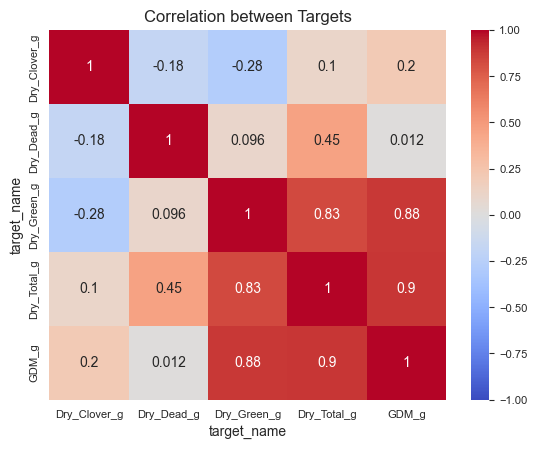

In [9]:
correlation_matrix = target_df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation between Targets")
plt.show()


                                             |          | [  0%]   00:00 -> (? left)


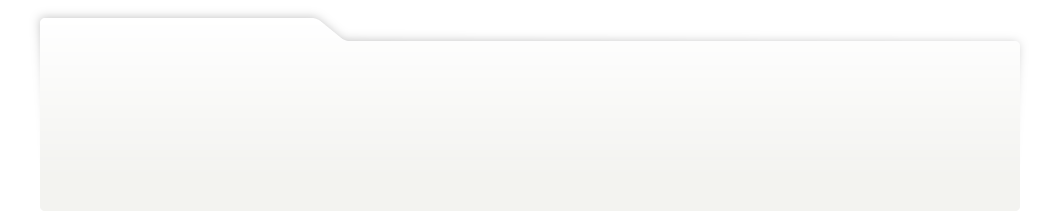
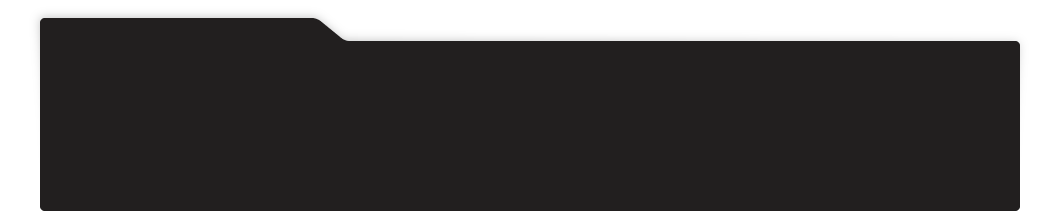
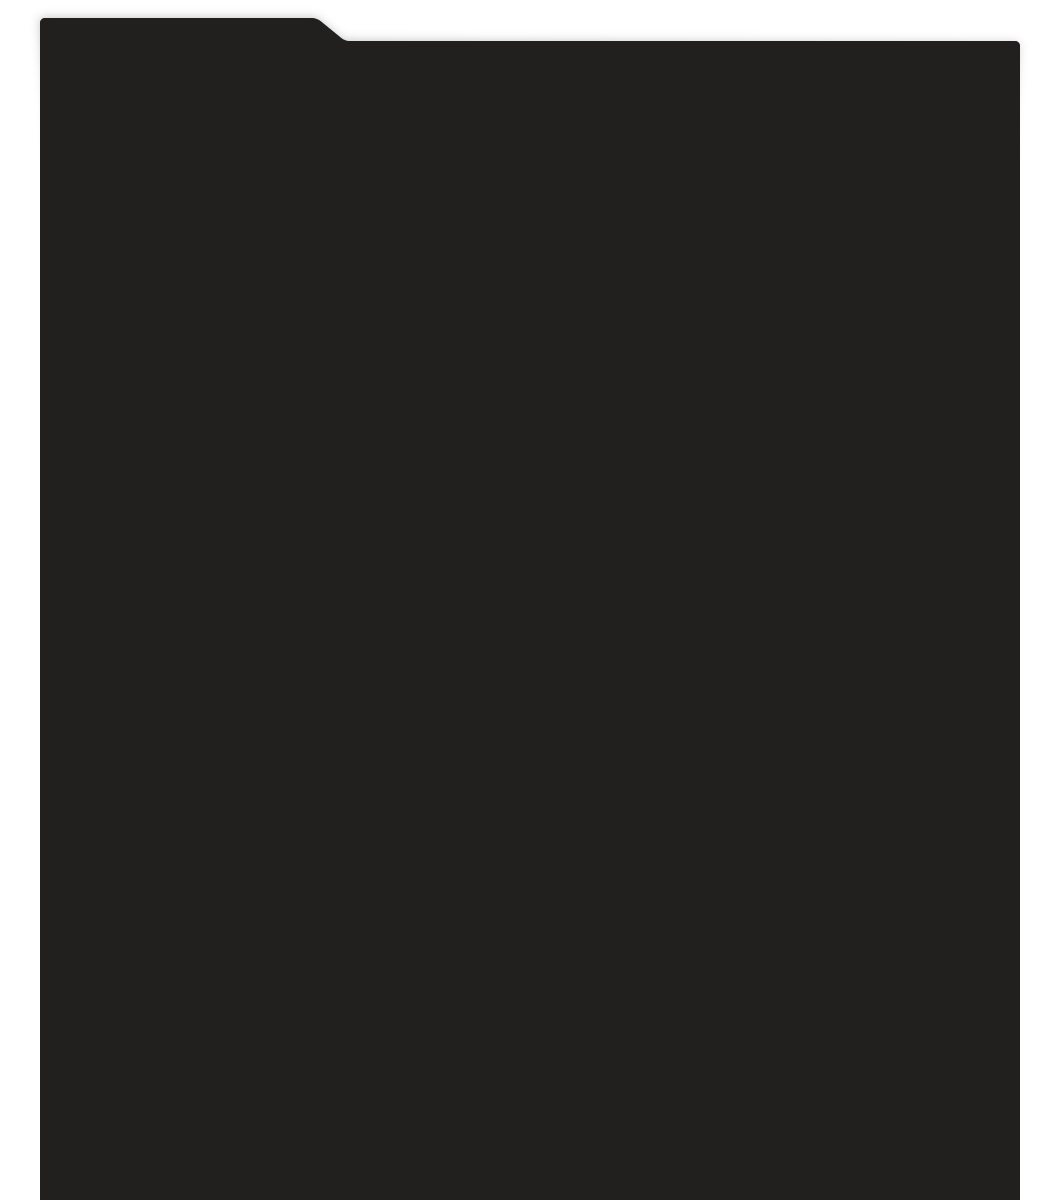
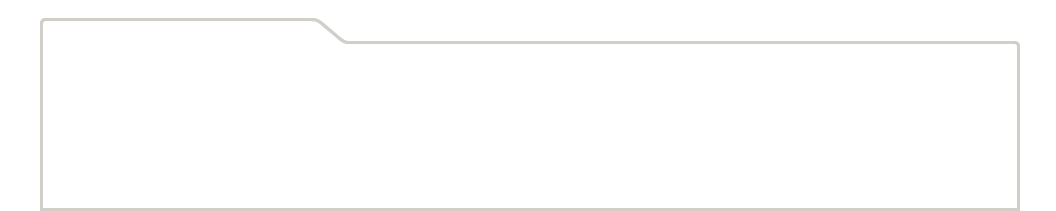
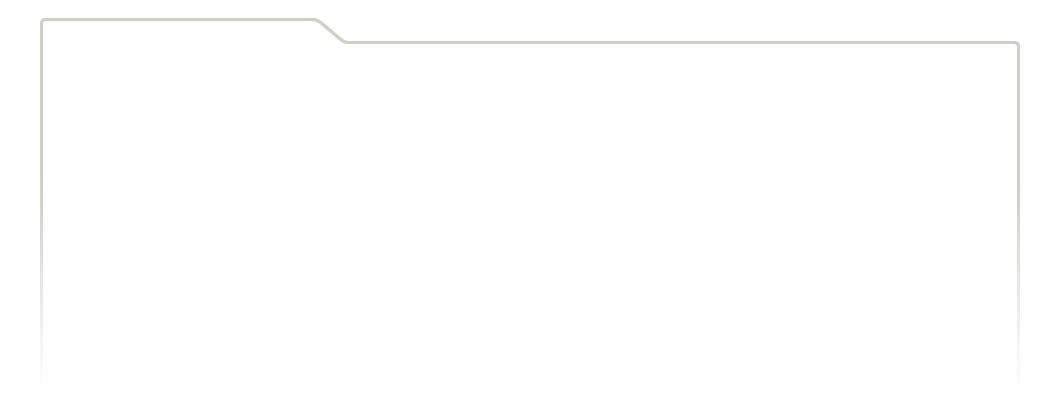
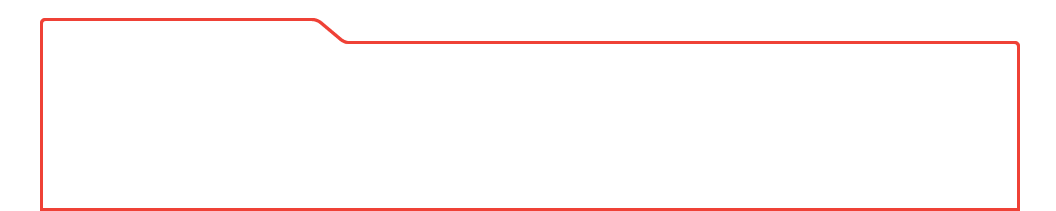
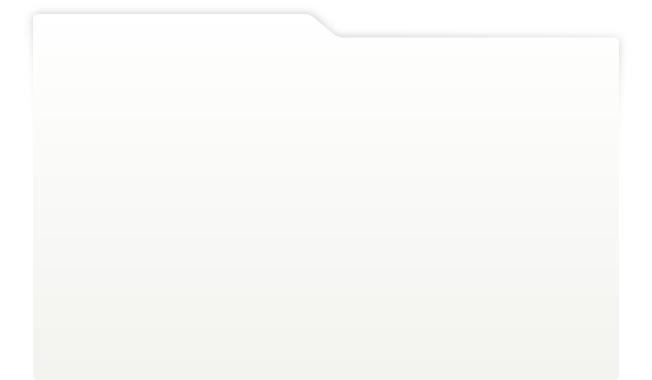
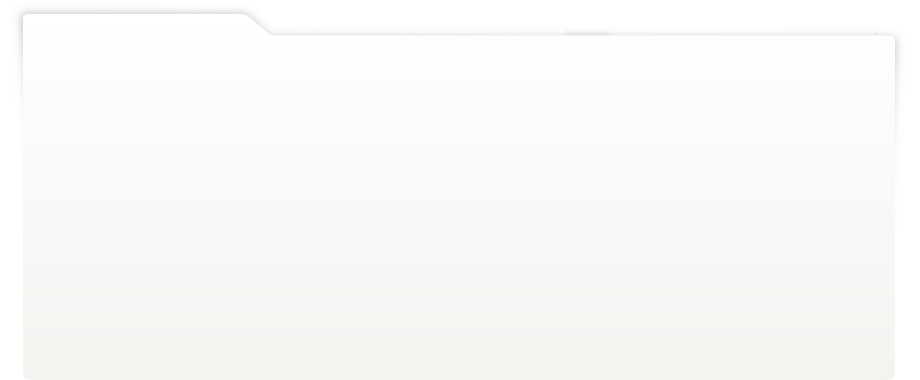
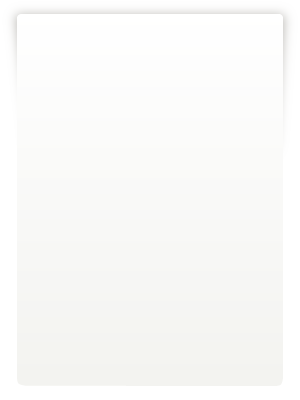
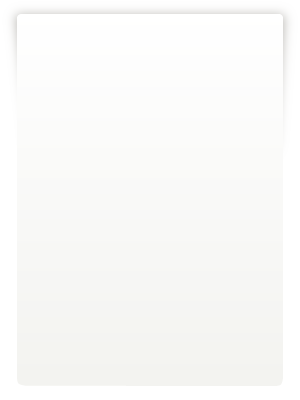
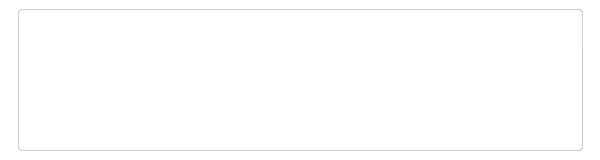
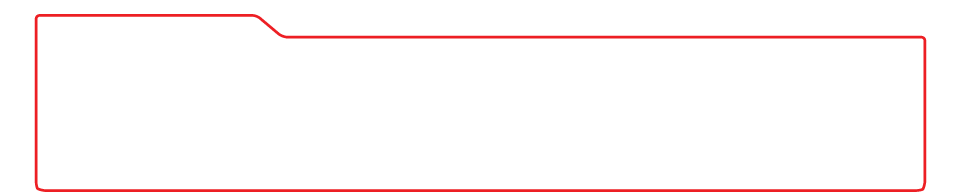
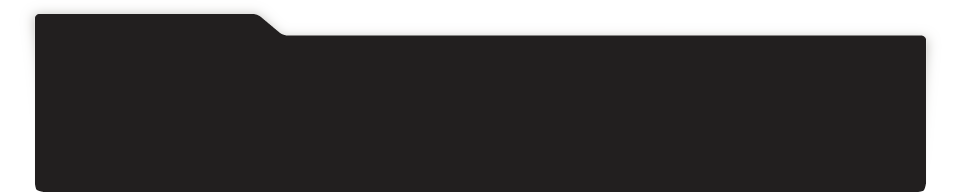
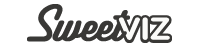
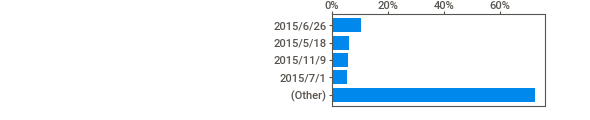
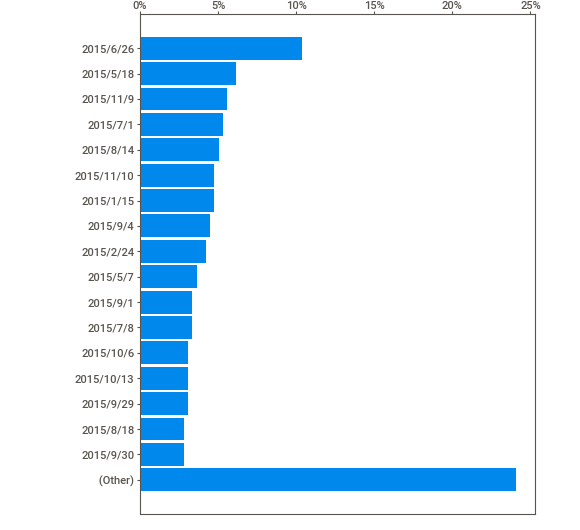
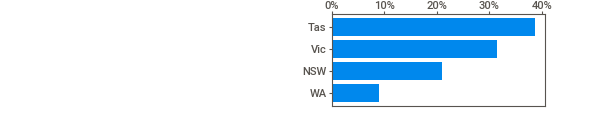
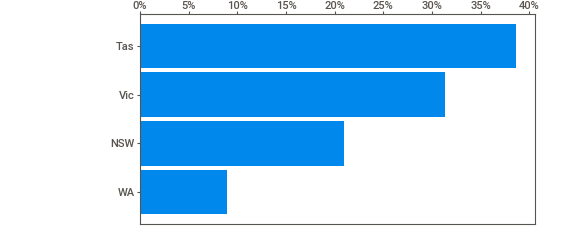
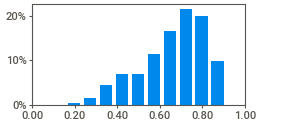
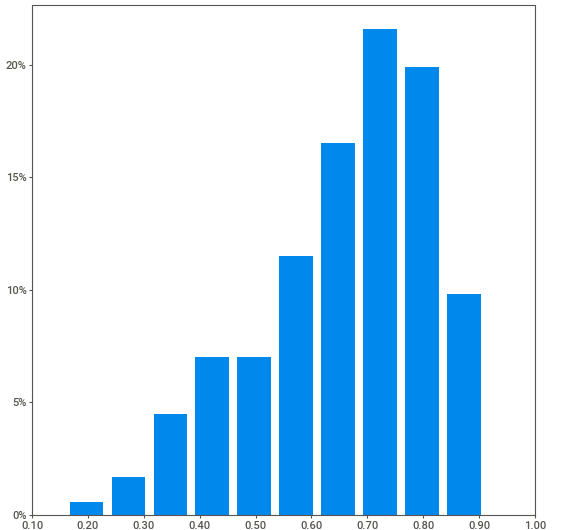
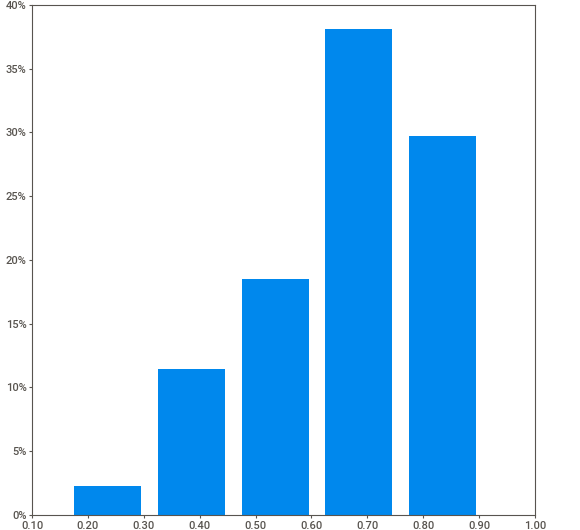
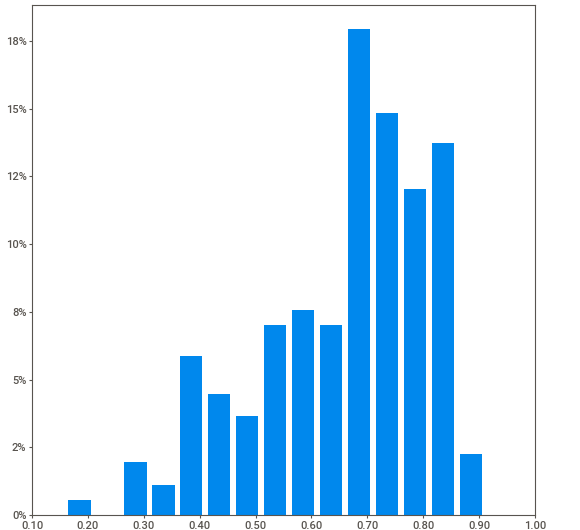
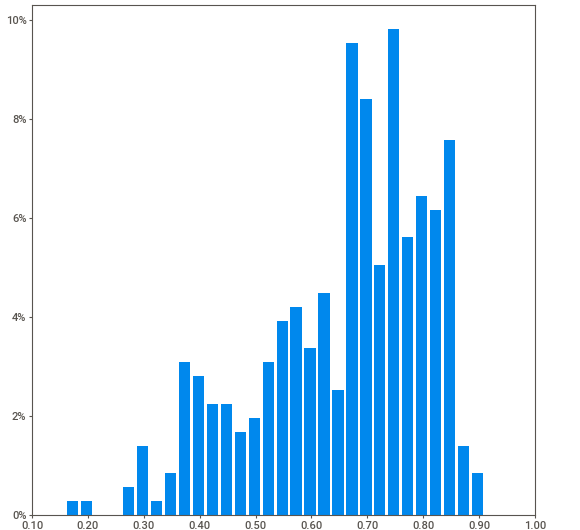
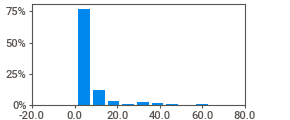
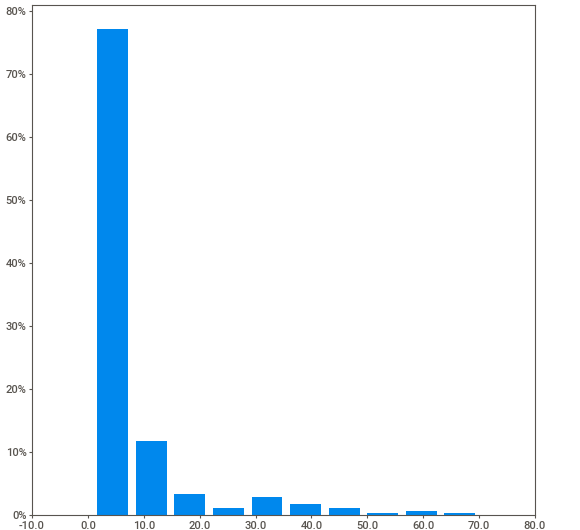
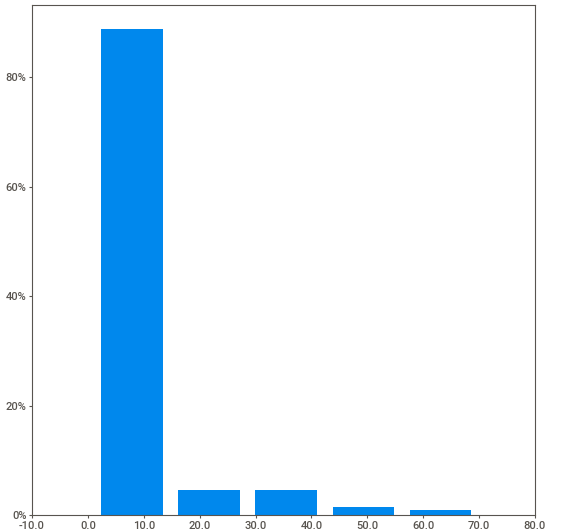
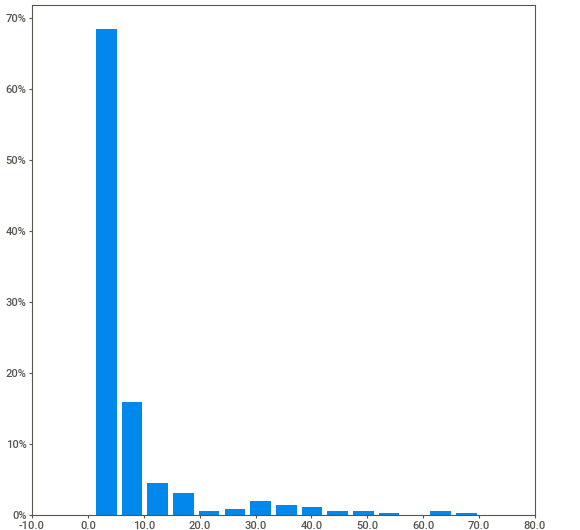
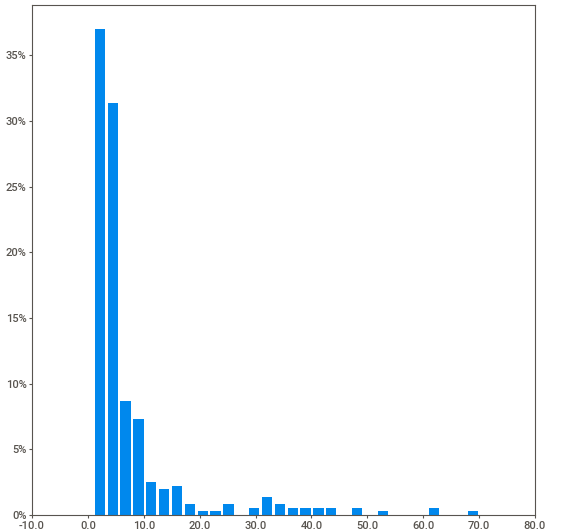
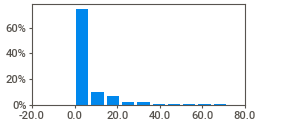
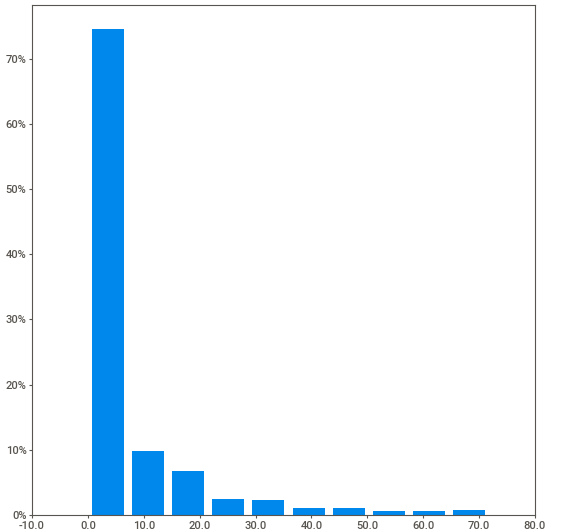
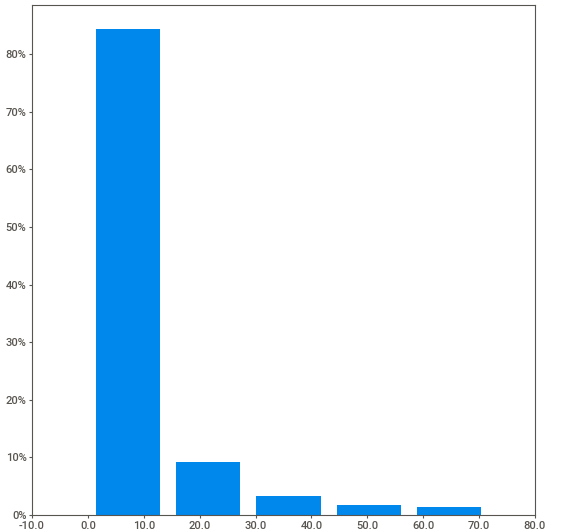
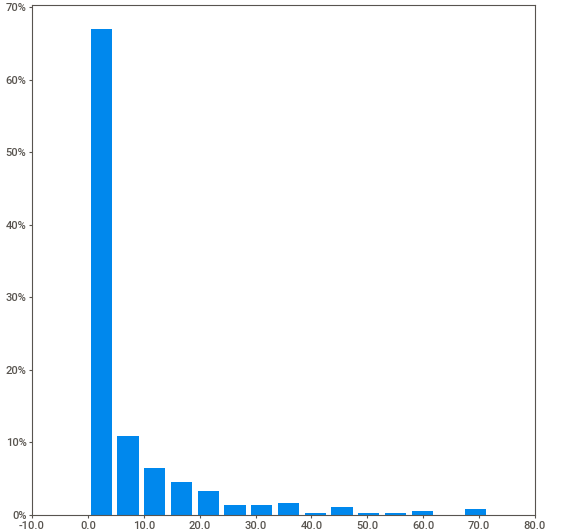
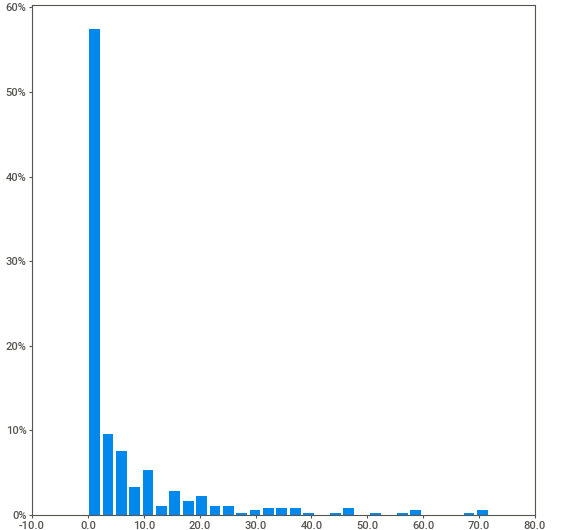
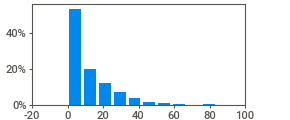
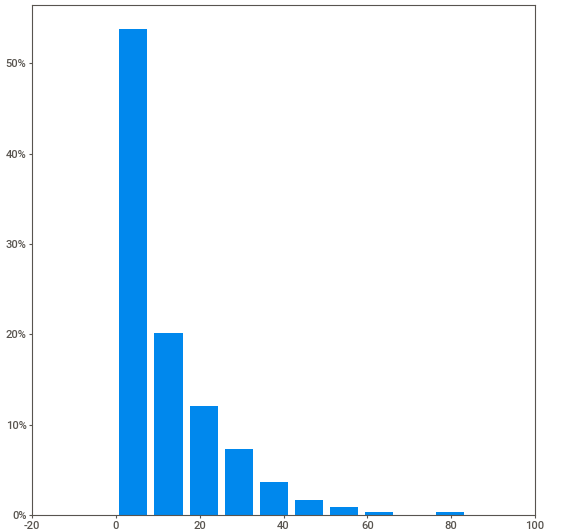
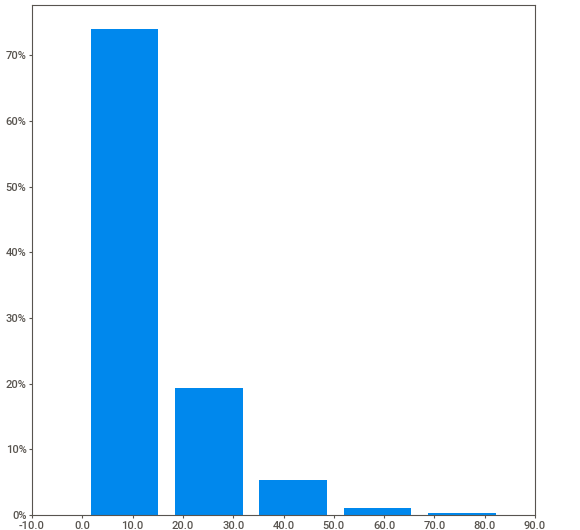
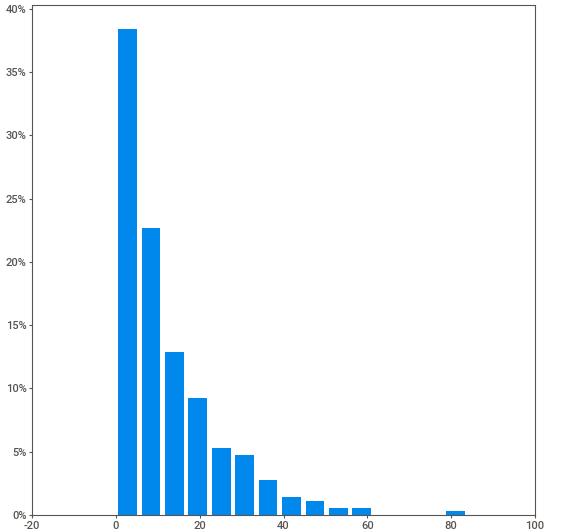
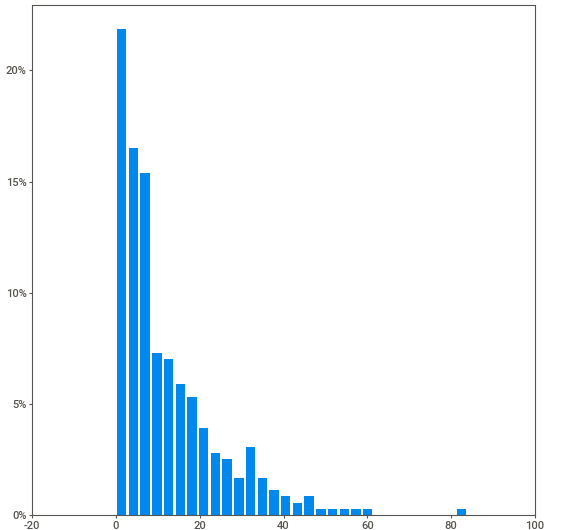
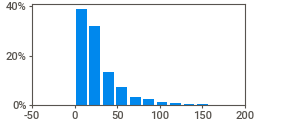
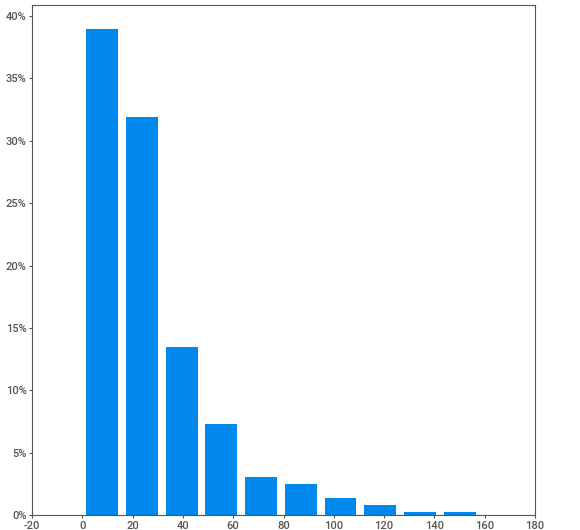
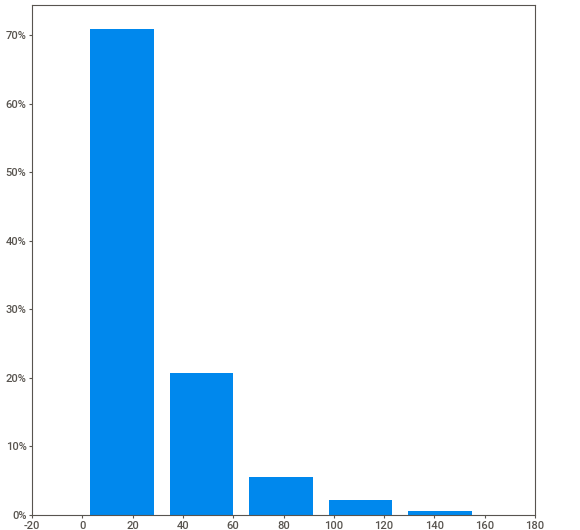
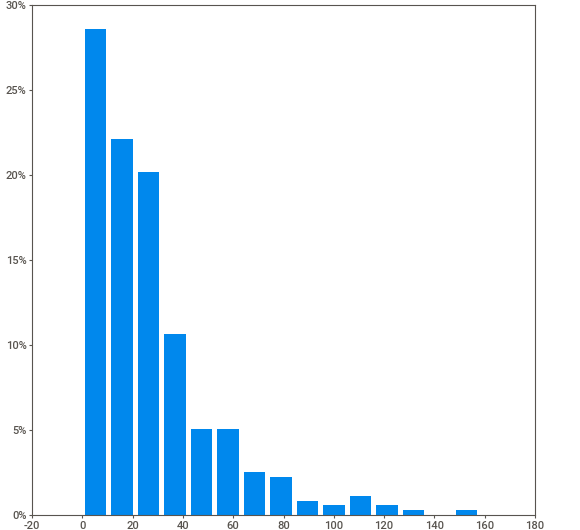
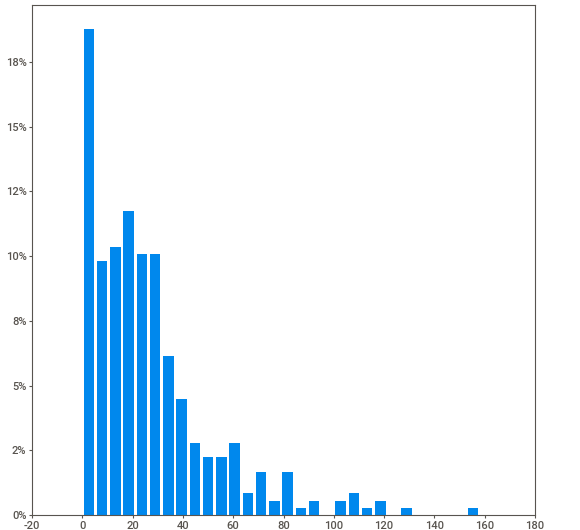
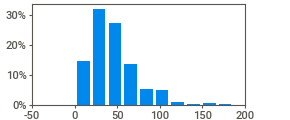
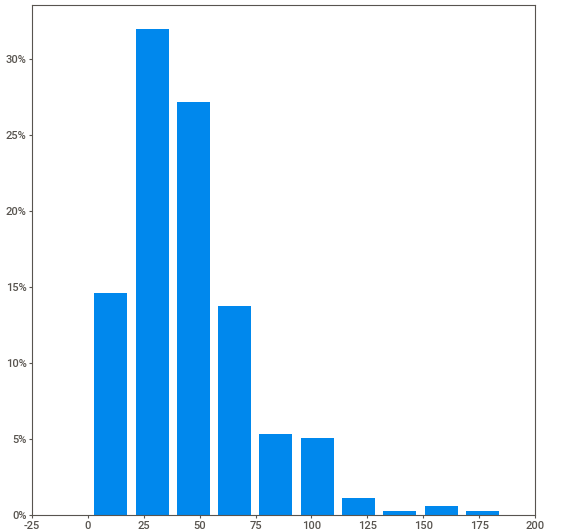
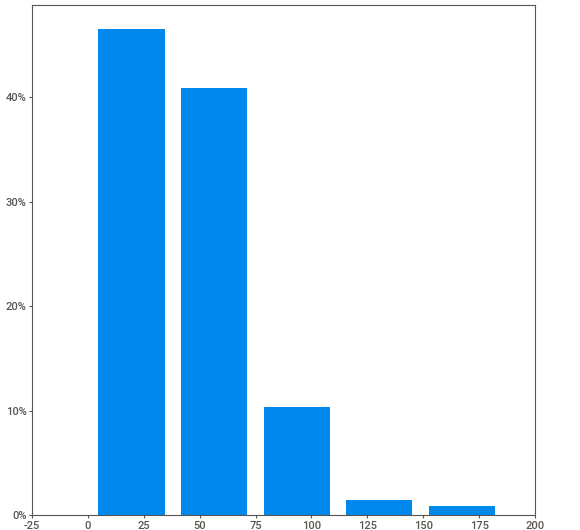
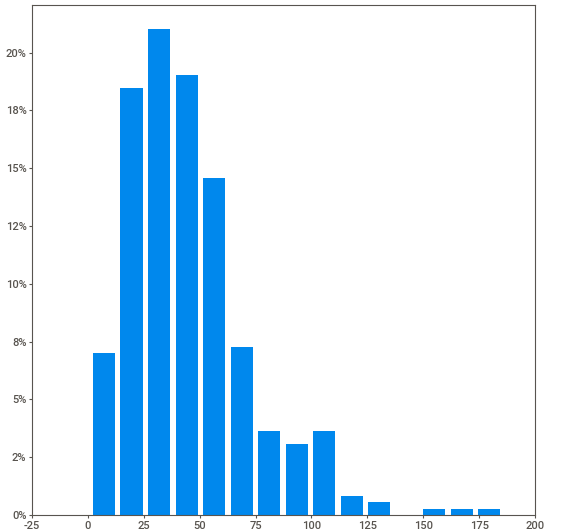
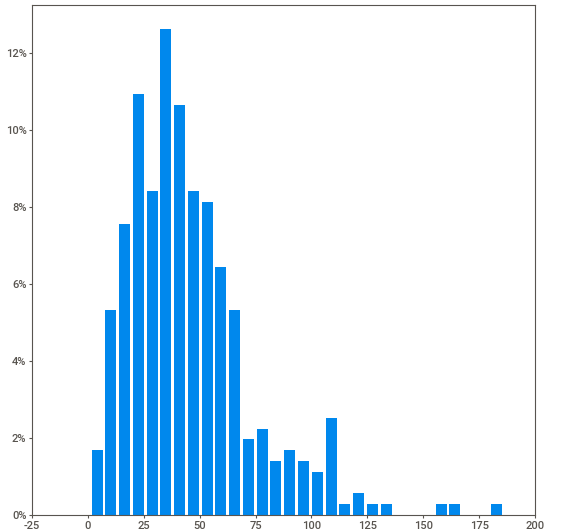
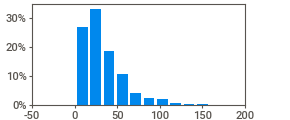
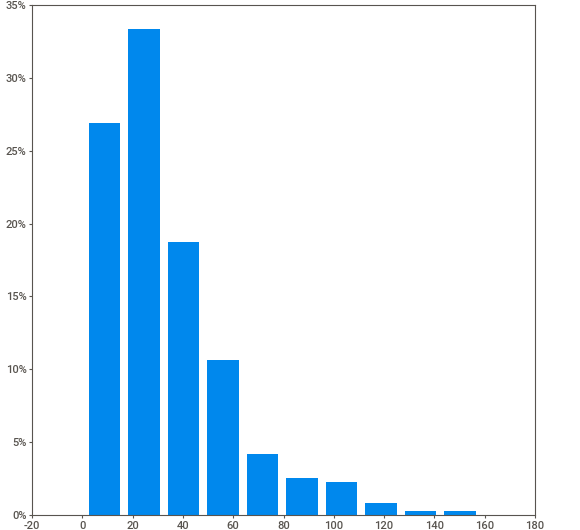
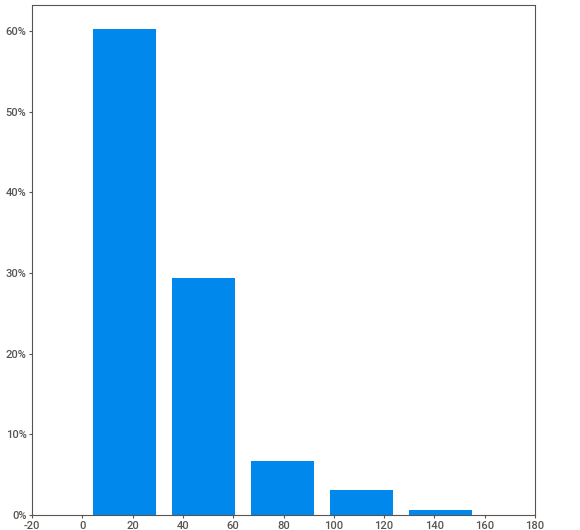
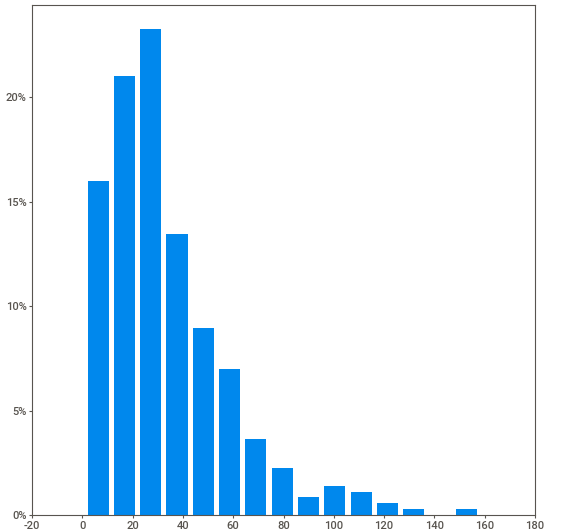
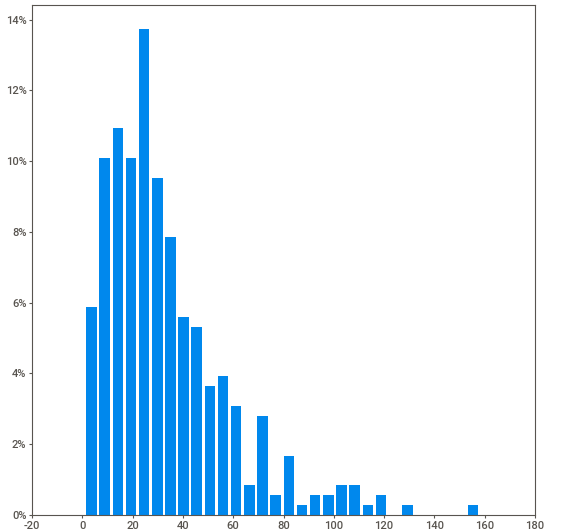
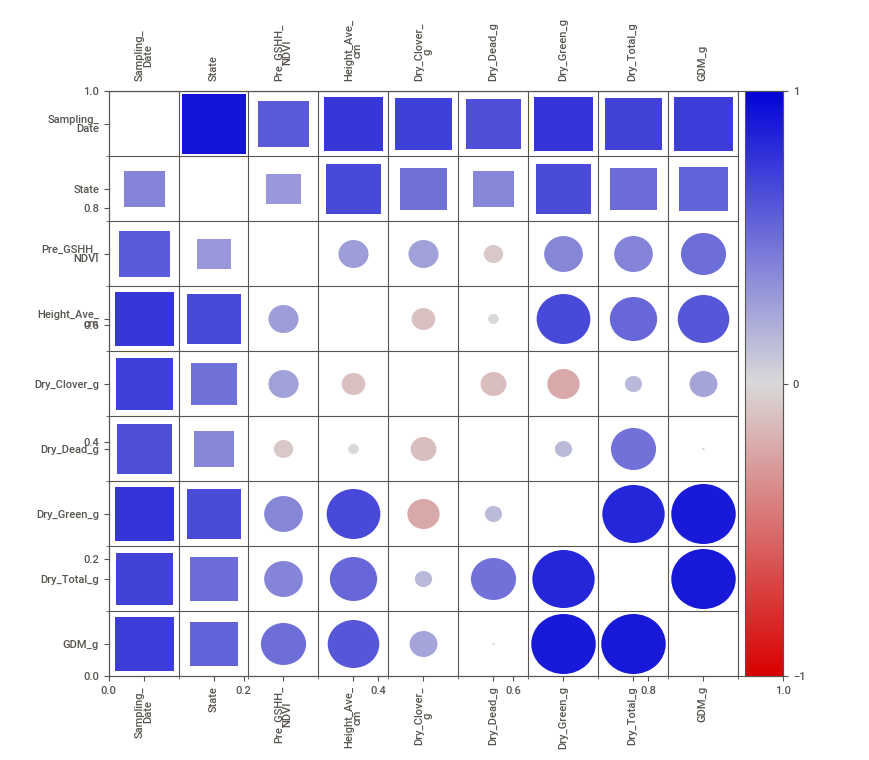
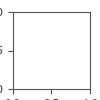

In [10]:
import sweetviz as sv

train_df = train_df.pivot_table(index=["image_path", "Sampling_Date", "State", "Species", "Pre_GSHH_NDVI", "Height_Ave_cm"], columns="target_name", values="target").reset_index()


# # log transform
# train_df["Height_Ave_cm"] = train_df["Height_Ave_cm"].map(lambda x: np.log(x))
# train_df["Dry_Green_g"] = train_df["Dry_Green_g"].map(lambda x: np.log(1 + x))
# train_df["Dry_Dead_g"] = train_df["Dry_Dead_g"].map(lambda x: np.log(1 + x))
# train_df["Dry_Clover_g"] = train_df["Dry_Clover_g"].map(lambda x: np.log(1 + x))
# train_df["GDM_g"] = train_df["GDM_g"].map(lambda x: np.log(1 + x))
# train_df["Dry_Total_g"] = train_df["Dry_Total_g"].map(lambda x: np.log(1 + x))

report = sv.analyze(
    train_df,
    feat_cfg=sv.FeatureConfig(skip=["image_path", "Species"])
)
report.show_notebook(w="100%", h="full")

The average value of `Dry_Clover_g` is smaller than `Dry_Green_g` and `Dry_Dead_g`. Therefore, `Dry_Clover_g` contribute smaller to `GDM_g` and `Dry_Total_g` (smaller correlation).

## Check Hypothesis

Average difference between theoretical and true Dry_Total_g: -0.0008655462184869675
Average difference between theoretical and true GDM_g: -8.40336134239108e-07


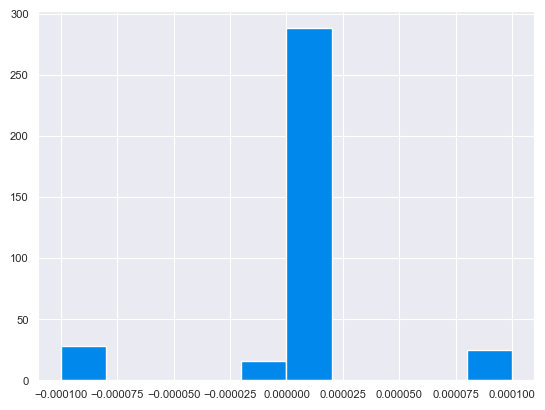

In [11]:
dry_total_g_errors = []
gdm_g_errors = []
for idx, row in train_df.iterrows():
    theo_dry_total_g = row["Dry_Green_g"] + row["Dry_Clover_g"] + row["Dry_Dead_g"]
    theo_gdm_g = row["Dry_Green_g"] + row["Dry_Clover_g"]
    dry_total_g = row["Dry_Total_g"]
    gdm_g = row["GDM_g"]
    dry_total_g_errors.append((dry_total_g - theo_dry_total_g))
    gdm_g_errors.append((gdm_g - theo_gdm_g))

print(f"Average difference between theoretical and true Dry_Total_g: {sum(dry_total_g_errors) / len(train_df)}")
print(f"Average difference between theoretical and true GDM_g: {sum(gdm_g_errors) / len(train_df)}")
plt.hist(gdm_g_errors)
plt.show()


## Pre_GSHH_NDVI vs Targets
The Normalized Difference Vegetation Index (NDVI) is a metric used to analyze remote sensing measurements and assess the health and density of vegetation.

Theoretically, Green Grass and Clover contribute largely to NDVI, and Dead material gives low NDVI.

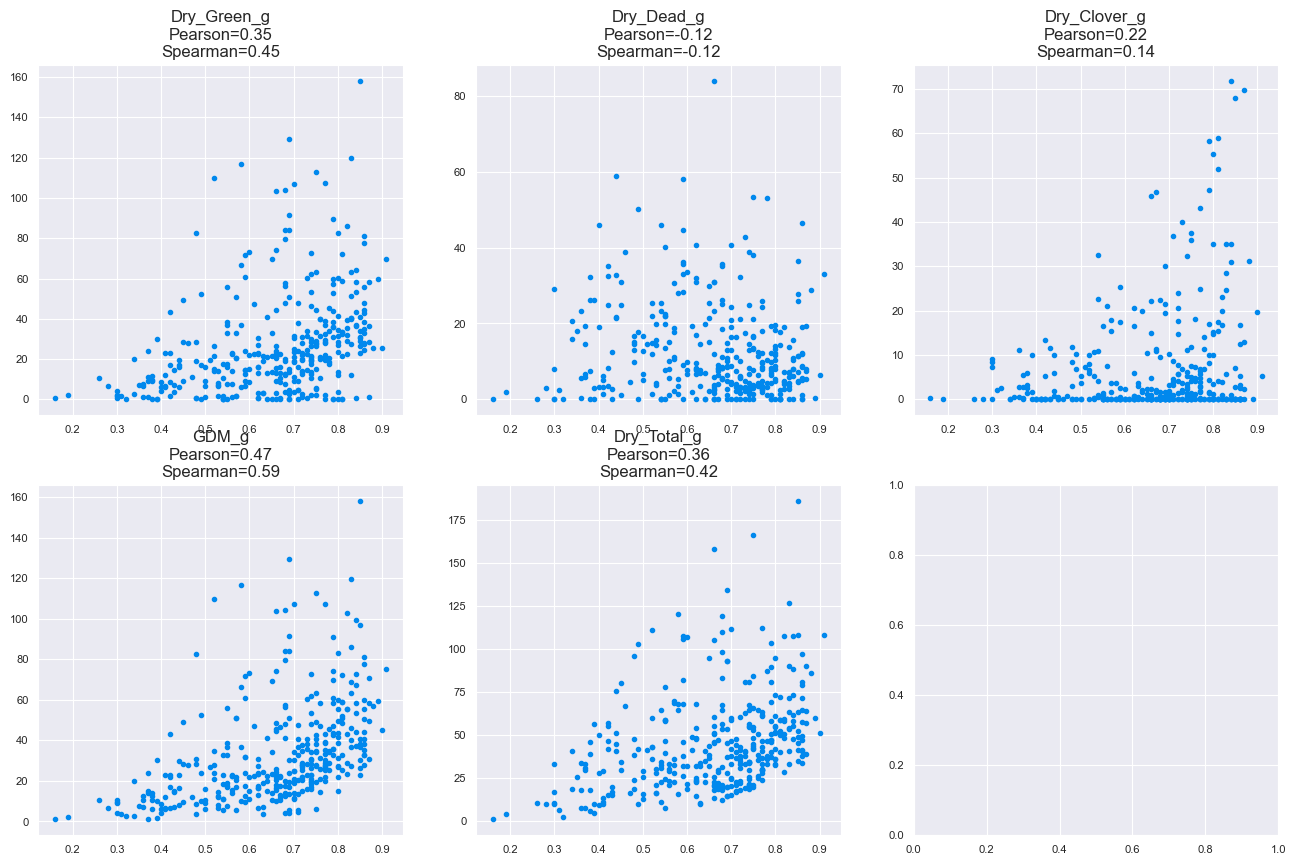

In [12]:
import scipy.stats as stats

targets = ["Dry_Green_g", "Dry_Dead_g", "Dry_Clover_g", "GDM_g", "Dry_Total_g"]
fig, axs = plt.subplots(2, 3, figsize=(16, 10))
for i in range(2):
    for j in range(3):
        if (3 * i + j) >= len(targets):
            break
        axs[i, j].scatter(train_df["Pre_GSHH_NDVI"], train_df[targets[3 * i + j]])
        pearson_r, _ = stats.pearsonr(train_df["Pre_GSHH_NDVI"], train_df[targets[3 * i + j]])
        spearman_rho, _ = stats.spearmanr(train_df["Pre_GSHH_NDVI"], train_df[targets[3 * i + j]])
        axs[i, j].set_title(f"{targets[3 * i + j]}\nPearson={pearson_r:.2}\nSpearman={spearman_rho:.2}")

plt.show()

`Pre_GSHH_NDVI` has relationship with `GDM_G`, `Dry_Total_g`

## Height_Ave_cm vs Targets

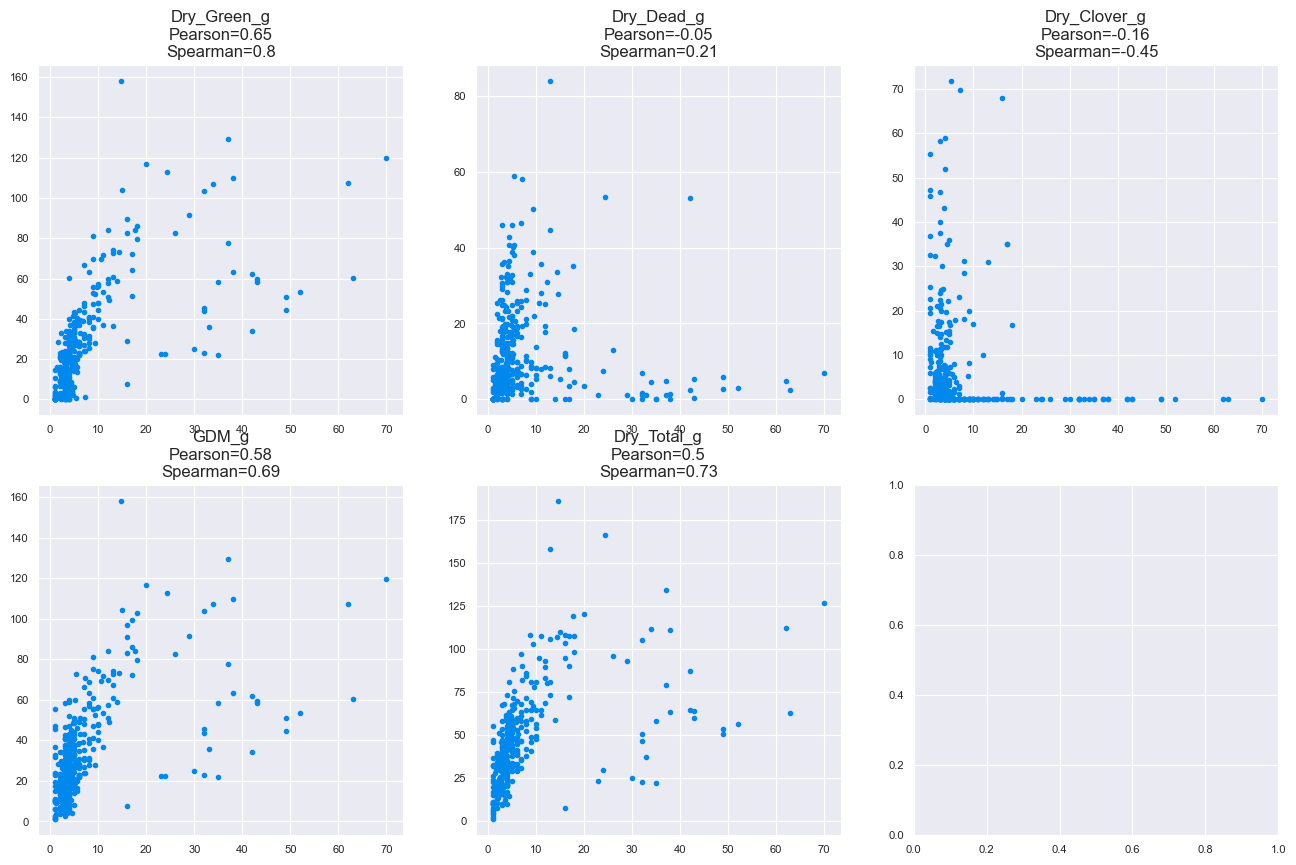

In [13]:
targets = ["Dry_Green_g", "Dry_Dead_g", "Dry_Clover_g", "GDM_g", "Dry_Total_g"]
fig, axs = plt.subplots(2, 3, figsize=(16, 10))
for i in range(2):
    for j in range(3):
        if (3 * i + j) >= len(targets):
            break
        axs[i, j].scatter(train_df["Height_Ave_cm"], train_df[targets[3 * i + j]])
        pearson_r, _ = stats.pearsonr(train_df["Height_Ave_cm"], train_df[targets[3 * i + j]])
        spearman_rho, _ = stats.spearmanr(train_df["Height_Ave_cm"], train_df[targets[3 * i + j]])
        axs[i, j].set_title(f"{targets[3 * i + j]}\nPearson={pearson_r:.2}\nSpearman={spearman_rho:.2}")

plt.show()

`Height_Ave_cm` has relationship with `Dry_Green`, `GDM_g`, `Dry_Total_g`

## Pre_GSHH_NDVI vs Height_Ave_cm

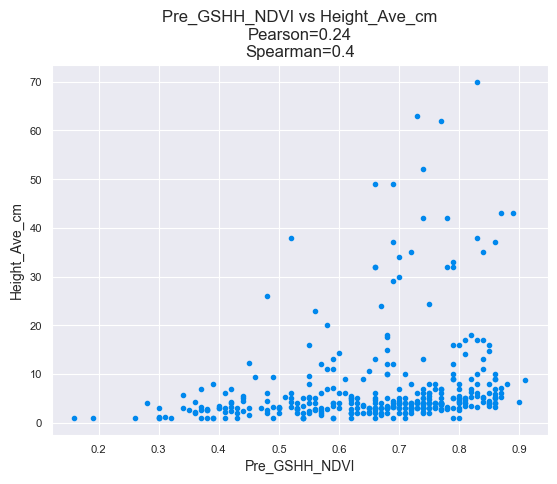

In [14]:
plt.scatter(train_df["Pre_GSHH_NDVI"], train_df["Height_Ave_cm"])
plt.xlabel("Pre_GSHH_NDVI")
plt.ylabel("Height_Ave_cm")
pearson_r, _ = stats.pearsonr(train_df["Pre_GSHH_NDVI"], train_df["Height_Ave_cm"])
spearman_rho, _ = stats.spearmanr(train_df["Pre_GSHH_NDVI"], train_df["Height_Ave_cm"])
plt.title(f"Pre_GSHH_NDVI vs Height_Ave_cm\nPearson={pearson_r:.2}\nSpearman={spearman_rho:.2}")
plt.show()

Low relationship between `Pre_GSHH_NDVI` and `Height_Ave_cm`

## Date

### Date vs Targets

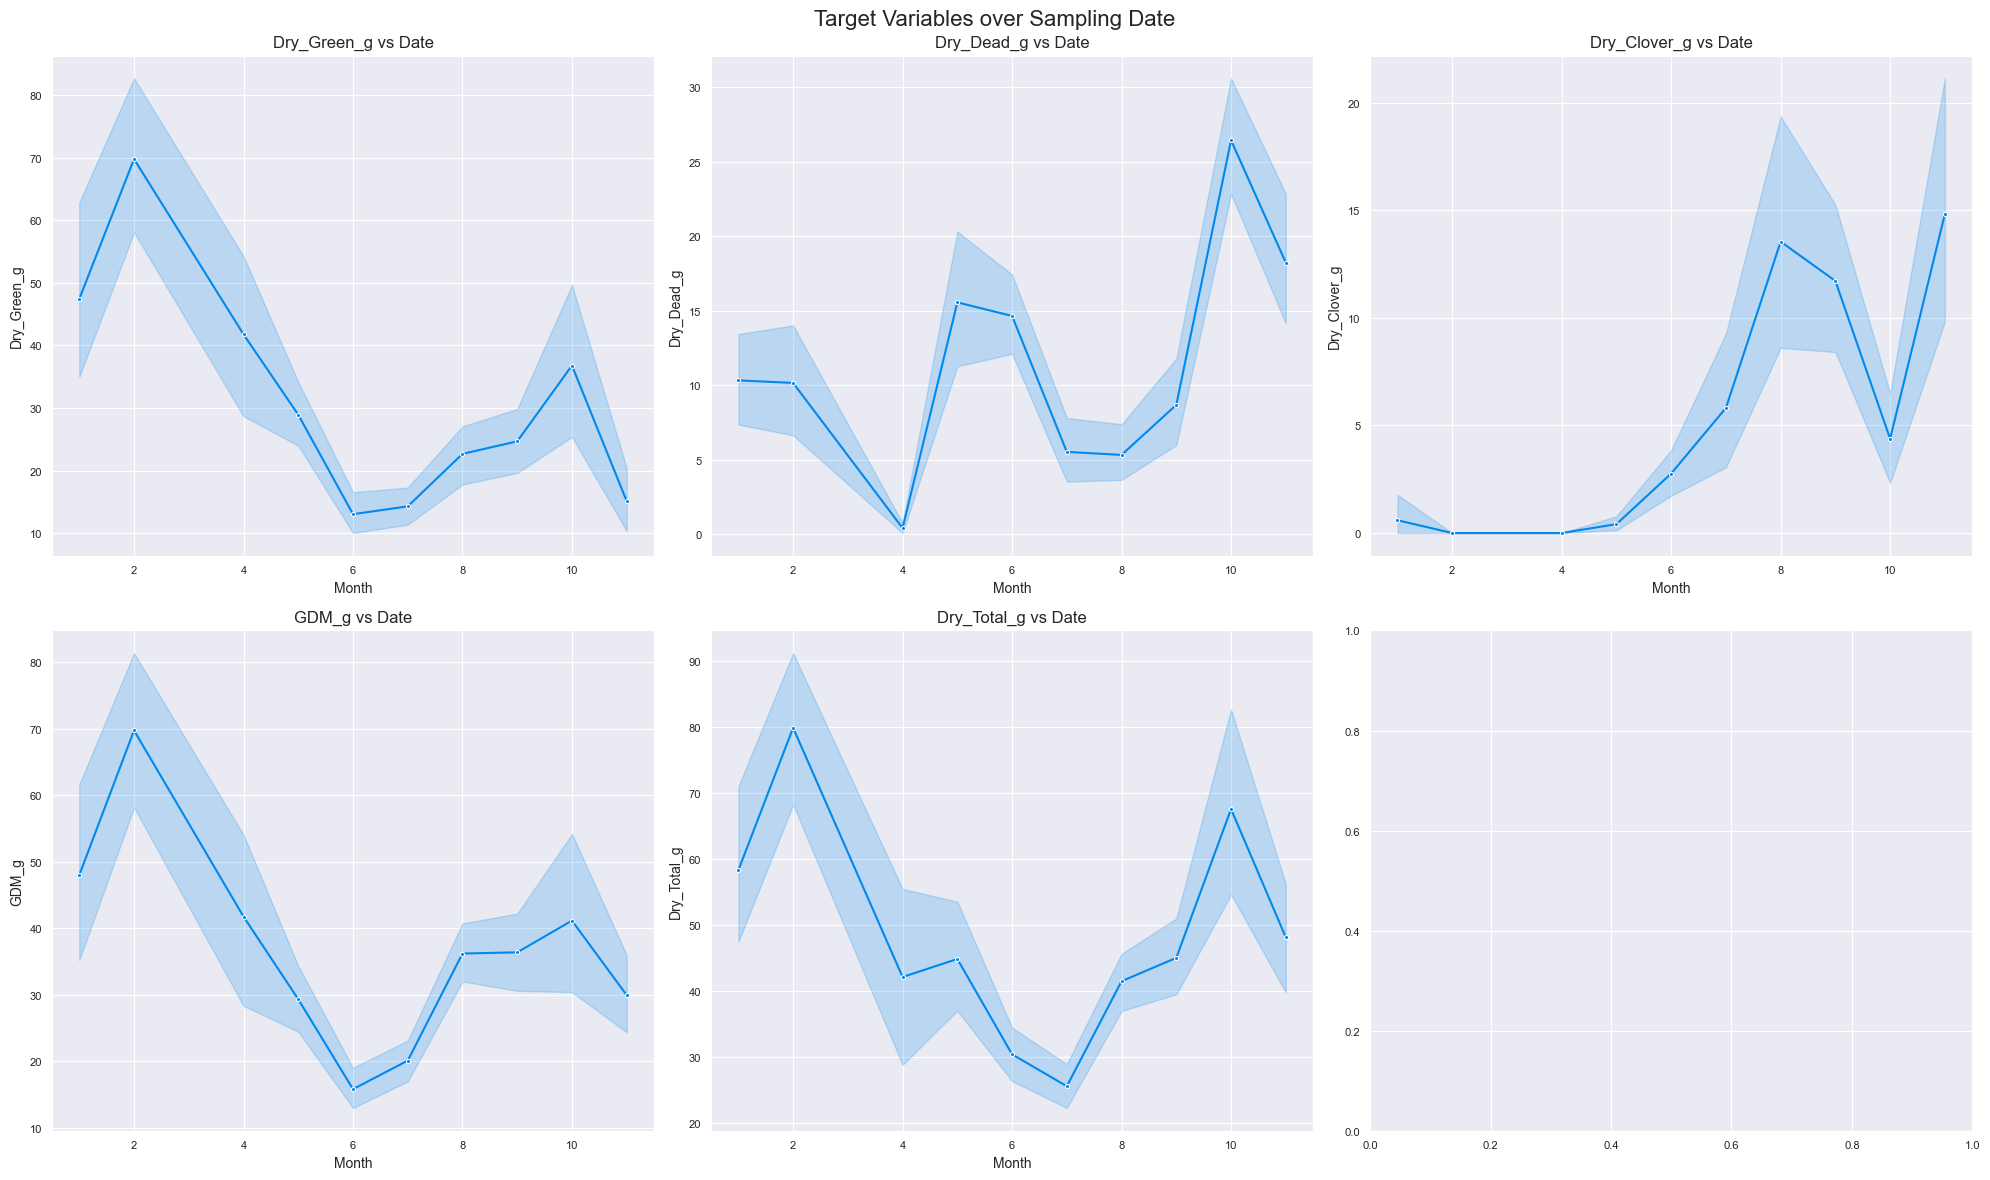

In [15]:
train_df["Sampling_Date"] = pd.to_datetime(train_df["Sampling_Date"])
seasons = ["Summer", "Fall", "Winter", "Spring"]
season_mapping = {
    12: 'Summer', 1: 'Summer', 2: 'Summer',
    3: 'Fall',   4: 'Fall',   5: 'Fall',
    6: 'Winter', 7: 'Winter', 8: 'Winter',
    9: 'Spring', 10: 'Spring', 11: 'Spring'
}
train_df["Month"] = train_df["Sampling_Date"].dt.month

fig, axs = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Target Variables over Sampling Date', fontsize=16)
axs = axs.flatten()

for i, target in enumerate(targets):
    if i < len(axs):
        # Lineplot aggregates data (mean) and shows a confidence interval (shaded area)
        sns.lineplot(data=train_df, x='Month', y=target, ax=axs[i], marker='o')
        axs[i].set_title(f'{target} vs Date')

plt.tight_layout()
plt.show()




## Species

### Species Distribution

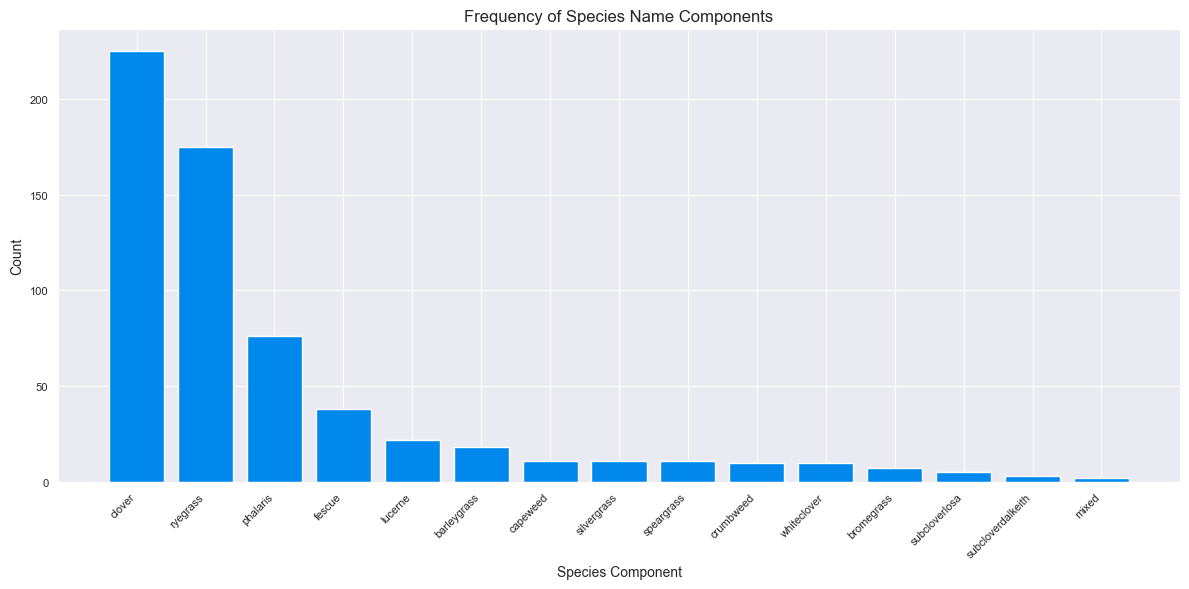

In [16]:
single_species = sorted(train_df["Species"].map(lambda x: x.lower().split("_")).explode().unique().tolist())
single_species_cnt = []
for specie in single_species:
    single_species_cnt.append(len(train_df[train_df["Species"].str.contains(specie, case=False)]))

zipped_lists = zip(single_species, single_species_cnt)
sorted_pairs = sorted(zipped_lists, key=lambda x: x[1], reverse=True)
single_species, single_species_cnt = zip(*sorted_pairs)

# 4. Plot
plt.figure(figsize=(12, 6))
plt.bar(single_species, single_species_cnt)
plt.title("Frequency of Species Name Components")
plt.xlabel("Species Component")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


### Species vs Pre_GSHH_NDVI

,count,mean,std,median
Species,,,,
Ryegrass_Clover,98,0.657551,0.152194,0.700
Ryegrass,62,0.668710,0.137071,0.690
Phalaris_Clover,42,0.772143,0.061229,0.775
Clover,41,0.605366,0.180556,0.640
Fescue,28,0.605000,0.139111,0.595
Lucerne,22,0.747727,0.092218,0.755
Phalaris_BarleyGrass_SilverGrass_SpearGrass_Clover_Capeweed,11,0.404545,0.062348,0.380
Fescue_CrumbWeed,10,0.686000,0.089963,0.680
WhiteClover,10,0.584000,0.106792,0.595


Text(0.5, 1.0, 'Pre_GSHH_NDVI')

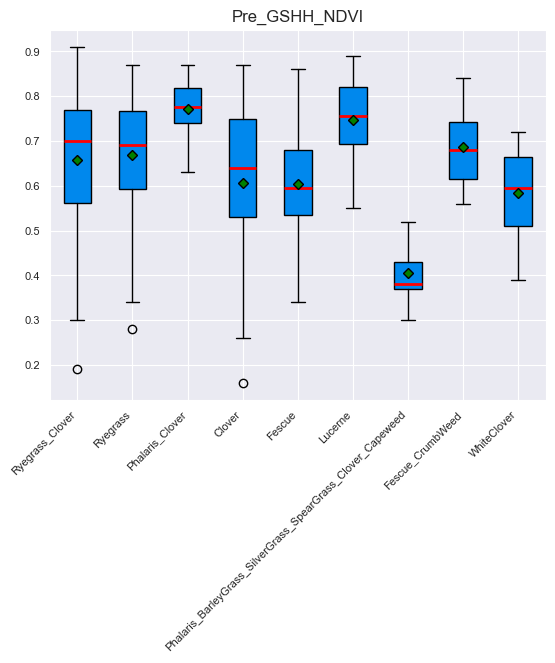

In [17]:
species = sorted(train_df["Species"].map(lambda x: x.lower()).unique().tolist())
species_stats = train_df.groupby("Species")["Pre_GSHH_NDVI"].agg(["count", "mean", "std", "median"])
significant_species_stats = species_stats[species_stats['count'] >= 10].sort_values(by='count', ascending=False)
display(significant_species_stats)

datas = [train_df.loc[train_df["Species"] == specie, "Pre_GSHH_NDVI"] for specie in significant_species_stats.index]
plt.boxplot(
    datas,
    tick_labels=significant_species_stats.index,
    showmeans=True,
    meanprops={"marker": "D", "markerfacecolor": "green", "markeredgecolor": "black", "markersize": 5},
    medianprops={"color": "red", "linewidth": 2},
    patch_artist=True
)
plt.setp(plt.gca().get_xticklabels(), rotation=45, ha="right")
plt.title("Pre_GSHH_NDVI")

### Species vs Height_Ave_cm

,count,mean,std,median
Species,,,,
Ryegrass_Clover,98,3.792517,2.582105,3.0000
Ryegrass,62,5.836021,3.053334,5.0000
Phalaris_Clover,42,6.028571,3.961478,4.9000
Clover,41,2.585366,1.404418,2.6667
Fescue,28,10.595239,4.745675,10.1667
Lucerne,22,40.090909,13.398326,37.5000
Phalaris_BarleyGrass_SilverGrass_SpearGrass_Clover_Capeweed,11,3.354545,0.710442,3.2000
Fescue_CrumbWeed,10,7.100000,2.558211,6.0000
WhiteClover,10,2.300000,0.674949,2.0000


Text(0.5, 1.0, 'Height_Ave_cm')

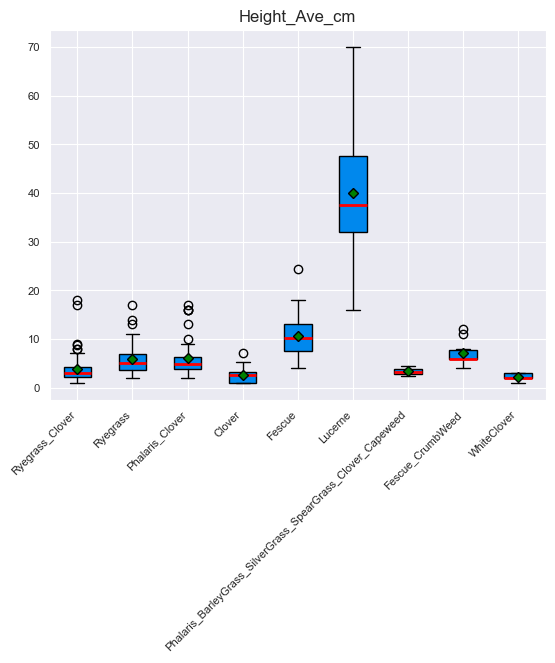

In [18]:
species = sorted(train_df["Species"].map(lambda x: x.strip().lower()).unique().tolist())
species_stats = train_df.groupby("Species")["Height_Ave_cm"].agg(["count", "mean", "std", "median"])
significant_species_stats = species_stats[species_stats['count'] >= 10].sort_values(by='count', ascending=False)
display(significant_species_stats)

datas = [train_df.loc[train_df["Species"] == specie, "Height_Ave_cm"] for specie in significant_species_stats.index]
plt.boxplot(
    datas,
    tick_labels=significant_species_stats.index,
    showmeans=True,
    meanprops={"marker": "D", "markerfacecolor": "green", "markeredgecolor": "black", "markersize": 5},
    medianprops={"color": "red", "linewidth": 2},
    patch_artist=True
)
plt.setp(plt.gca().get_xticklabels(), rotation=45, ha="right")
plt.title("Height_Ave_cm")

### Species vs Targets

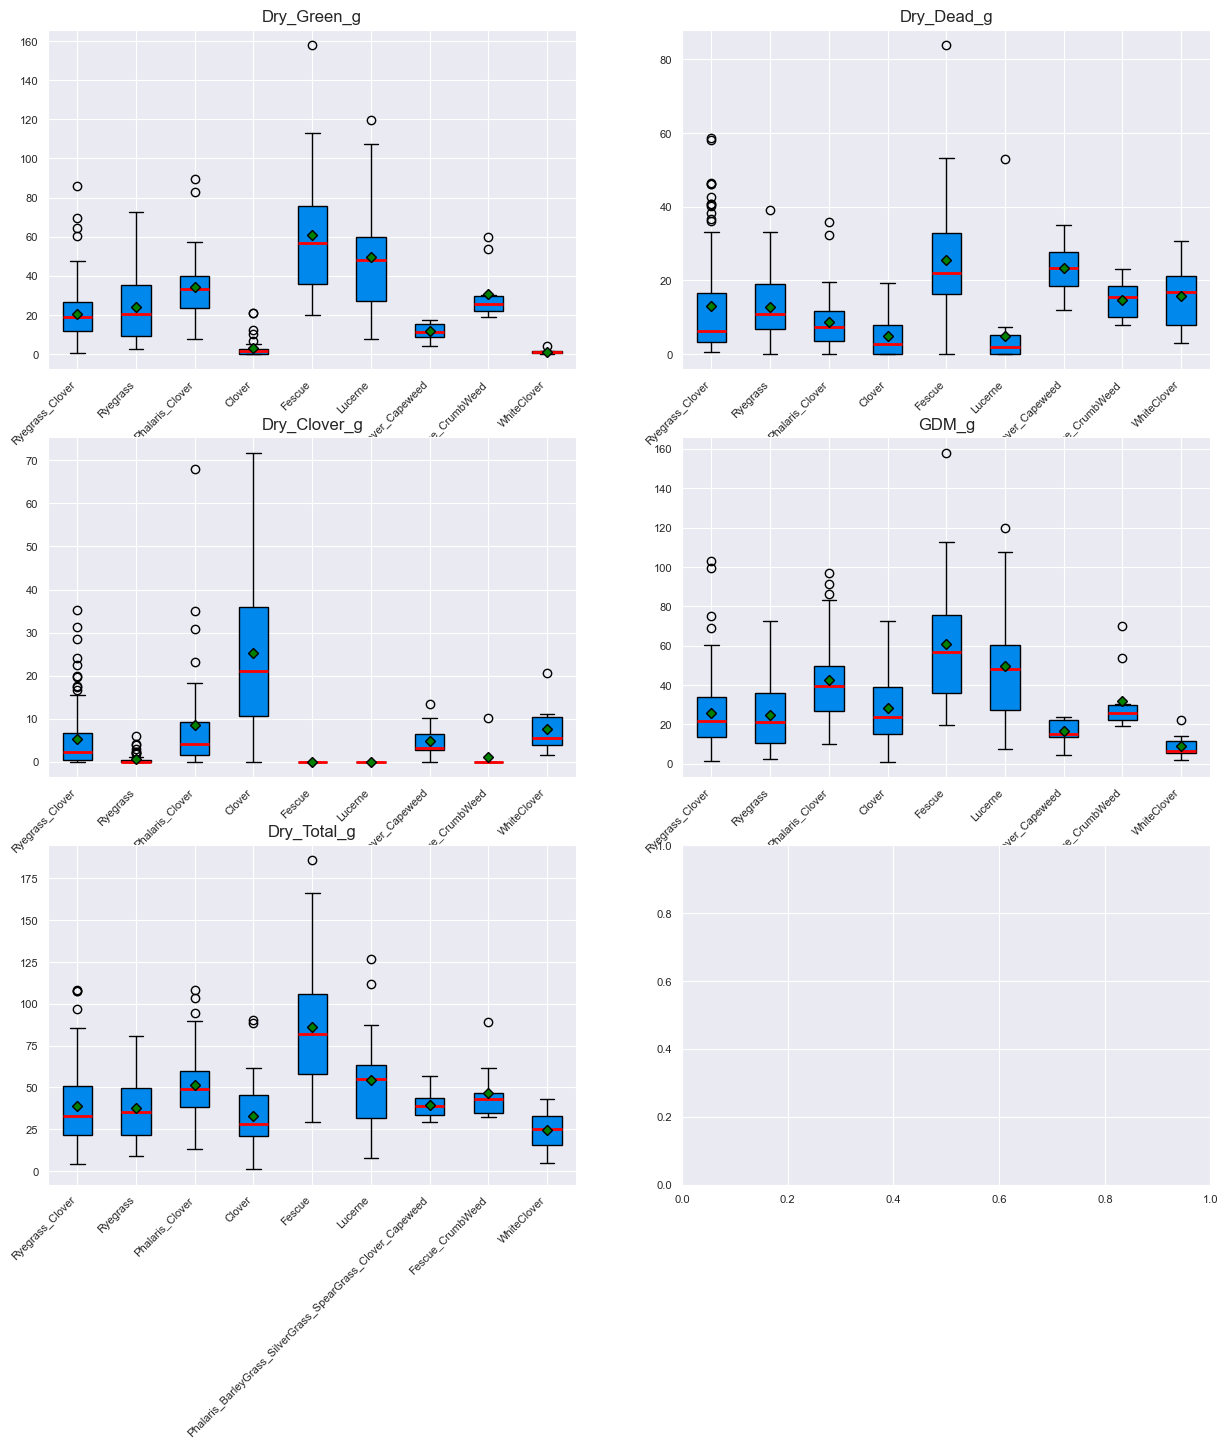

In [19]:
species = sorted(train_df["Species"].map(lambda x: x.strip().lower()).unique().tolist())
species_stats = train_df.groupby("Species")[targets].agg(["count", "mean", "std", "median"])
significant_species_stats = species_stats[species_stats[targets[0]]['count'] >= 10].sort_values(by=(targets[0], 'count'), ascending=False)
styled_df = significant_species_stats.style \
    .format("{:.0f}", subset=pd.IndexSlice[:, (slice(None), 'count')]) \
    .format("{:.2f}", subset=pd.IndexSlice[:, (slice(None), ['mean', 'std', 'median'])]) \
    .set_properties(**{'text-align': 'center'}) \
    .set_properties(
        subset=pd.IndexSlice[:, (slice(None), 'median')],
        **{'border-right': '3px solid #666666'} # Add border to the right of every 'median' column
    ) \
    .set_table_styles([
        {'selector': 'th', 'props': [('text-align', 'center')]},
        {'selector': 'caption', 'props': [('caption-side', 'bottom')]}
    ])

display(styled_df)
fig, axs = plt.subplots(3, 2, figsize=(15, 15))
for i in range(3):
    for j in range(2):
        if (2 * i + j) >= len(targets):
            continue
        target = targets[2 * i + j]
        datas = [train_df.loc[train_df["Species"] == specie, target] for specie in significant_species_stats.index]
        axs[i, j].boxplot(
            datas,
            tick_labels=significant_species_stats.index,
            showmeans=True,
            meanprops={"marker": "D", "markerfacecolor": "green", "markeredgecolor": "black", "markersize": 5},
            medianprops={"color": "red", "linewidth": 2},
            patch_artist=True
        )
        plt.setp(axs[i, j].get_xticklabels(), rotation=45, ha="right")
        axs[i, j].set_title(target)


## States


### States vs Targets

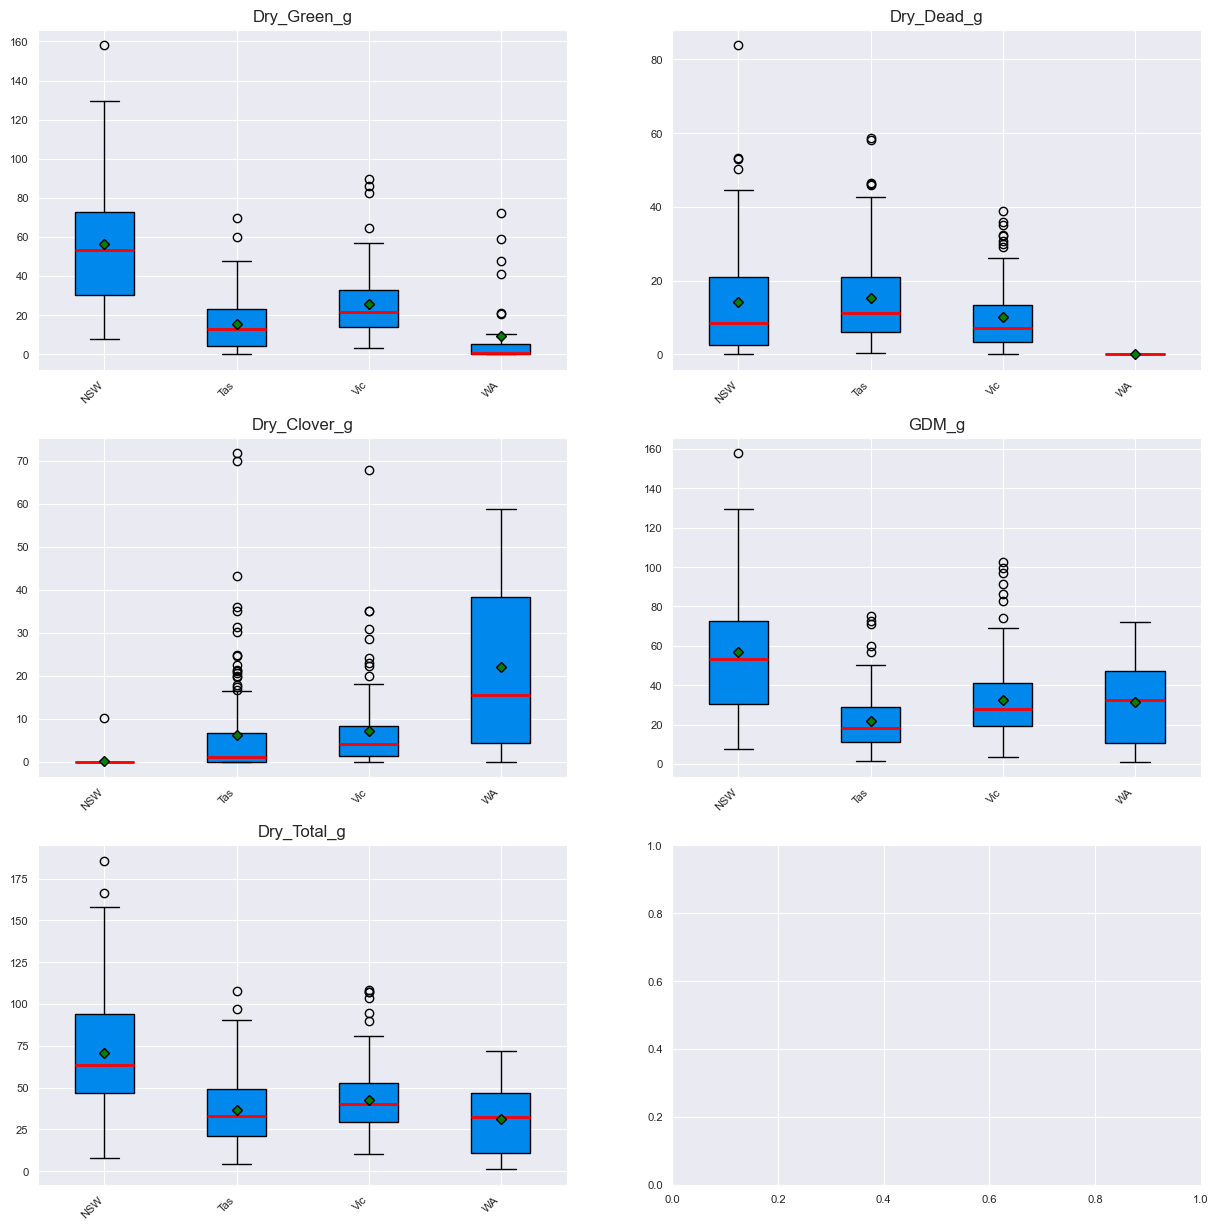

In [20]:
states = sorted(train_df["State"].unique().tolist())
state_stats = train_df.groupby("State")[targets].agg(["count", "mean", "std", "median"]).round(2)
state_stats = state_stats.sort_values(by=(targets[0], 'count'), ascending=False)
styled_df = state_stats.style \
    .format("{:.0f}", subset=pd.IndexSlice[:, (slice(None), 'count')]) \
    .format("{:.2f}", subset=pd.IndexSlice[:, (slice(None), ['mean', 'std', 'median'])]) \
    .set_properties(**{'text-align': 'center'}) \
    .set_properties(
        subset=pd.IndexSlice[:, (slice(None), 'median')],
        **{'border-right': '3px solid #666666'} # Add border to the right of every 'median' column
    ) \
    .set_table_styles([
        {'selector': 'th', 'props': [('text-align', 'center')]},
        {'selector': 'caption', 'props': [('caption-side', 'bottom')]}
    ])

display(styled_df)

fig, axs = plt.subplots(3, 2, figsize=(15, 15))
for i in range(3):
    for j in range(2):
        if (2 * i + j) >= len(targets):
            continue
        target = targets[2 * i + j]
        datas = [train_df.loc[train_df["State"] == state, target] for state in states]
        axs[i, j].boxplot(
            datas,
            tick_labels=states,
            showmeans=True,
            meanprops={"marker": "D", "markerfacecolor": "green", "markeredgecolor": "black", "markersize": 5},
            medianprops={"color": "red", "linewidth": 2},
            patch_artist=True
        )
        plt.setp(axs[i, j].get_xticklabels(), rotation=45, ha="right")
        axs[i, j].set_title(target)

### States vs Species

<Axes: title={'center': 'State vs Specie'}, xlabel='State'>

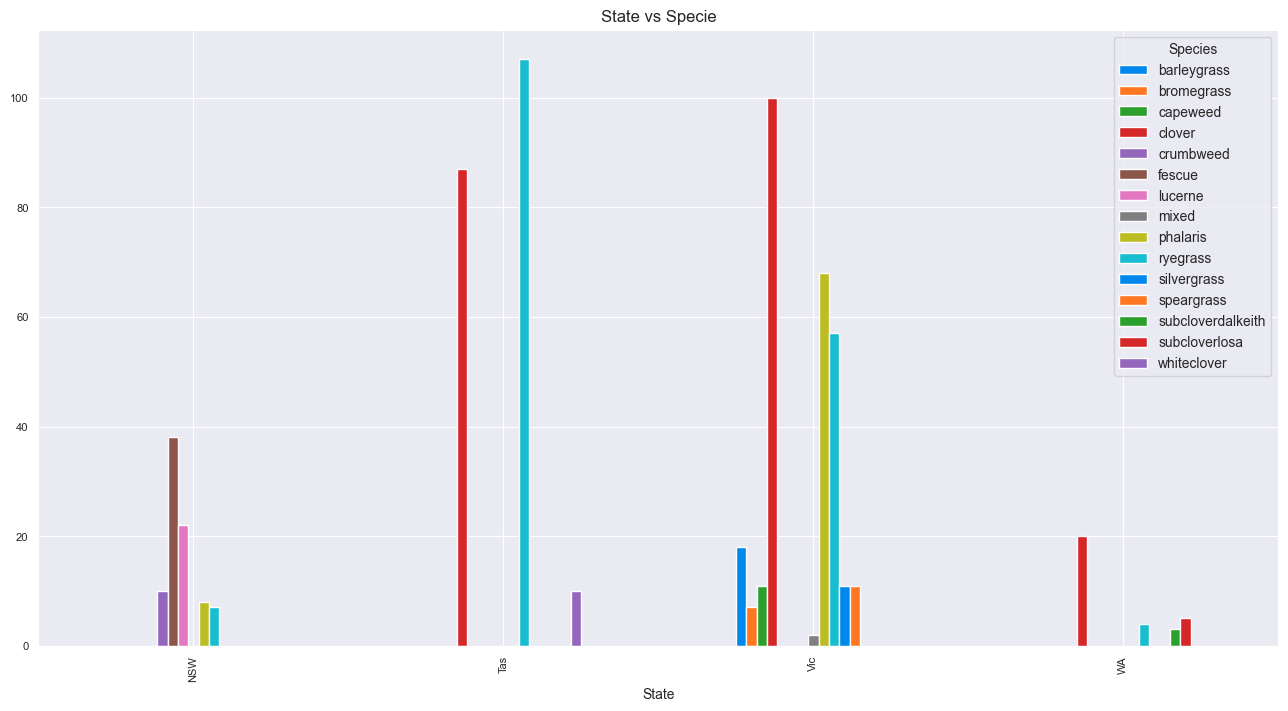

In [21]:
temp_df = train_df[["State", "Species"]].copy()
temp_df["Species"] = temp_df["Species"].map(lambda x: x.lower().split("_"))
exploded_df = temp_df.explode("Species")
pd.crosstab(exploded_df["State"], exploded_df["Species"]).plot(kind="bar", figsize=(16, 8), title="State vs Specie")






## Conclusion
### Observation
1. `Dry_Green_g` contribute more to the `Dry_Total_g` and `GDM_g` compared to `Dry_Clover_g` and `Dry_Dead_g`

2. High `Pre_DSHH_NDVI` indicate high `GMD_g` and `Dry_Total_g`, but not necessarily mean high `Dry_Green_g` or `Dry_Clover_g` since both of them can contribute to the `Pre_DSHH_NDVI`.

    Same for `Height_Ave_cm`.

3. Season does have effect on 5 targets.

4. Species has low effect on `Pre_DSHH_NDVI`.

5. Species has effect on `Height_Ave_cm`, especially for Lucerne and Fescue.

